# Merged ion centers — statistics

Uses the same merge pipeline as `merge_ion_centers.py` (`merge_centers_hybrid` + `fuse_detect_strip_by_distance`). Adjust parameters in the first code cell to match your CLI run.

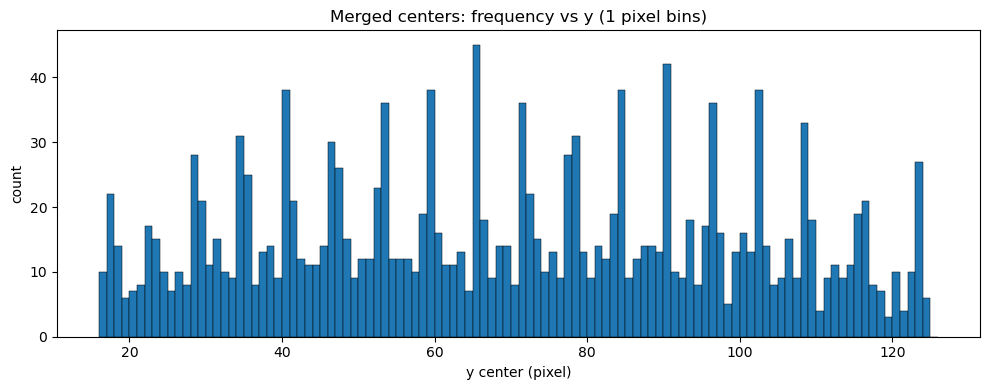

In [11]:
"""Histogram of merged-center y coordinates; bin width = 1 pixel."""

import matplotlib.pyplot as plt
import numpy as np

from output_paths import PROJECT_ROOT
from ion_detect.cli_helpers import resolve_indices
from ion_detect.edge_strip import outer_y_edge_column_profiles
from ion_detect.pipeline import detect_ions
from merge_ion_centers import (
    _strip_input_map,
    fuse_detect_strip_by_distance,
    merge_centers_hybrid,
)

# Match merge_ion_centers.py defaults (change to mirror your experiment)
DATA_DIR = PROJECT_ROOT / "20260305_1727"
INDICES_SPEC = ["800"]  # e.g. "::" or ["0", "1", "5"] — same syntax as CLI
EDGE_X_RANGE = (250.0, 750.0)
Y_EDGE_FRAC = 0.25
Y_FIT_FRAC = 0.35
PEAK_DIST = 5.0
COL_METRIC = "mean"
STRIP_CENTER_MODE = "com"
PREPROCESS = "raw"
CLIP_ELLIPSE = True
ION_DIST = 4.0

files = sorted(f for f in DATA_DIR.iterdir() if f.suffix == ".npy")
selected = resolve_indices(INDICES_SPEC, len(files))
xs: list[float] = []
ys: list[float] = []
frame_ids: list[int] = []

for idx in selected:
    target = files[idx]
    image = np.load(target)
    ions, boundary = detect_ions(image)
    if boundary is None:
        continue
    try:
        strip_map, _ = _strip_input_map(image, boundary, PREPROCESS, ions_for_peel=ions)
    except ValueError:
        continue
    strip_result = outer_y_edge_column_profiles(
        strip_map,
        boundary,
        Y_EDGE_FRAC,
        clip_ellipse=CLIP_ELLIPSE,
        col_metric=COL_METRIC,
    )
    merged, _stats = merge_centers_hybrid(
        ions,
        boundary,
        strip_map,
        strip_result=strip_result,
        edge_x_lo=EDGE_X_RANGE[0],
        edge_x_hi=EDGE_X_RANGE[1],
        peak_dist=PEAK_DIST,
        clip_ellipse=CLIP_ELLIPSE,
        y_fit_frac=float(Y_FIT_FRAC),
        strip_center_mode=STRIP_CENTER_MODE,
    )
    merged, _nf = fuse_detect_strip_by_distance(merged, float(ION_DIST))
    xs.extend(float(p["x0"]) for p in merged)
    ys.extend(float(p["y0"]) for p in merged)
    frame_ids.extend([int(idx)] * len(merged))

x_arr = np.asarray(xs, dtype=np.float64)
y_arr = np.asarray(ys, dtype=np.float64)
fid_arr = np.asarray(frame_ids, dtype=np.int64)
if y_arr.size == 0:
    raise RuntimeError("No merged centers; check DATA_DIR / INDICES_SPEC / preprocessing.")

# One-pixel-wide bins: [k, k+1) for integer k
y_lo = int(np.floor(y_arr.min()))
y_hi = int(np.ceil(y_arr.max()))
bin_edges = np.arange(y_lo, y_hi + 2, dtype=float)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(y_arr, bins=bin_edges, edgecolor="black", linewidth=0.35)
ax.set_xlabel("y center (pixel)")
ax.set_ylabel("count")
ax.set_title("Merged centers: frequency vs y (1 pixel bins)")
fig.tight_layout()
plt.show()

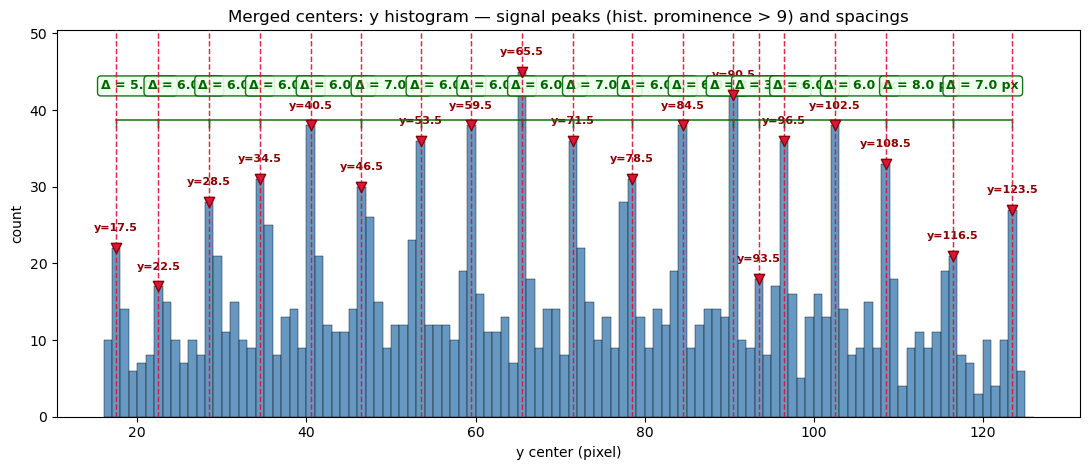

Signal peaks (n=19): y ≈ [ 17.5  22.5  28.5  34.5  40.5  46.5  53.5  59.5  65.5  71.5  78.5  84.5
  90.5  93.5  96.5 102.5 108.5 116.5 123.5]
Adjacent spacings (px): [5. 6. 6. 6. 6. 7. 6. 6. 6. 7. 6. 6. 3. 3. 6. 6. 8. 7.]


: 

In [ ]:
"""Signal peaks from the histogram (prominence > 10) and inter-peak spacings."""

from scipy.signal import find_peaks

if "y_arr" not in globals() or "bin_edges" not in globals():
    raise RuntimeError("Run the first code cell first to define y_arr and bin_edges.")

HIST_PROMINENCE = 9
counts, _ = np.histogram(y_arr, bins=bin_edges)
# scipy.find_peaks does not treat sequence endpoints as peaks; pad with 0 so
# the leftmost/rightmost histogram bins can be detected when they are maxima.
_counts = counts.astype(float)
_padded = np.concatenate([[0.0], _counts, [0.0]])
_ixp, _peak_props = find_peaks(_padded, prominence=HIST_PROMINENCE)
peak_ix = _ixp - 1
peak_ix = peak_ix[(peak_ix >= 0) & (peak_ix < counts.size)]

if peak_ix.size == 0:
    print(f"No histogram peaks with prominence > {HIST_PROMINENCE}.")
else:
    peak_y = 0.5 * (bin_edges[peak_ix] + bin_edges[peak_ix + 1])
    heights = counts[peak_ix].astype(float)
    sort_order = np.argsort(peak_y)
    peak_y = peak_y[sort_order]
    heights = heights[sort_order]
    spacings = np.diff(peak_y)

    ymax = float(np.max(counts)) if counts.size else 1.0
    y_bracket = ymax * 0.86
    y_lbl = ymax * 0.94

    fig, ax = plt.subplots(figsize=(11, 4.8))
    ax.hist(
        y_arr,
        bins=bin_edges,
        edgecolor="black",
        linewidth=0.35,
        alpha=0.82,
        color="steelblue",
    )

    for yi, hi in zip(peak_y, heights):
        ax.axvline(yi, color="crimson", linestyle="--", linewidth=1.05, alpha=0.92, zorder=4)
        ax.scatter([yi], [hi], color="crimson", s=55, zorder=6, marker="v", edgecolors="darkred")
        ax.annotate(
            f"y={yi:.1f}",
            xy=(yi, hi),
            xytext=(0, 12),
            textcoords="offset points",
            ha="center",
            fontsize=8,
            color="darkred",
            fontweight="bold",
        )

    for j in range(len(peak_y) - 1):
        y0, y1 = float(peak_y[j]), float(peak_y[j + 1])
        d = float(spacings[j])
        mid = 0.5 * (y0 + y1)
        ax.plot([y0, y1], [y_bracket, y_bracket], color="darkgreen", linewidth=1.2, alpha=0.85, zorder=3)
        ax.plot([y0, y0], [y_bracket - ymax * 0.02, y_bracket], color="darkgreen", lw=1.0, alpha=0.85)
        ax.plot([y1, y1], [y_bracket - ymax * 0.02, y_bracket], color="darkgreen", lw=1.0, alpha=0.85)
        ax.annotate(
            f"Δ = {d:.1f} px",
            xy=(mid, y_lbl),
            ha="center",
            va="bottom",
            fontsize=9,
            color="darkgreen",
            fontweight="bold",
            bbox=dict(
                boxstyle="round,pad=0.28",
                facecolor="honeydew",
                alpha=0.9,
                edgecolor="darkgreen",
            ),
        )

    ax.set_xlabel("y center (pixel)")
    ax.set_ylabel("count")
    ax.set_title(
        f"Merged centers: y histogram — signal peaks (hist. prominence > {HIST_PROMINENCE}) and spacings"
    )
    ax.set_ylim(0, ymax * 1.12)
    fig.tight_layout()
    plt.show()

    print(f"Signal peaks (n={len(peak_y)}): y ≈ {np.round(peak_y, 2)}")
    print(f"Adjacent spacings (px): {np.round(spacings, 2)}")


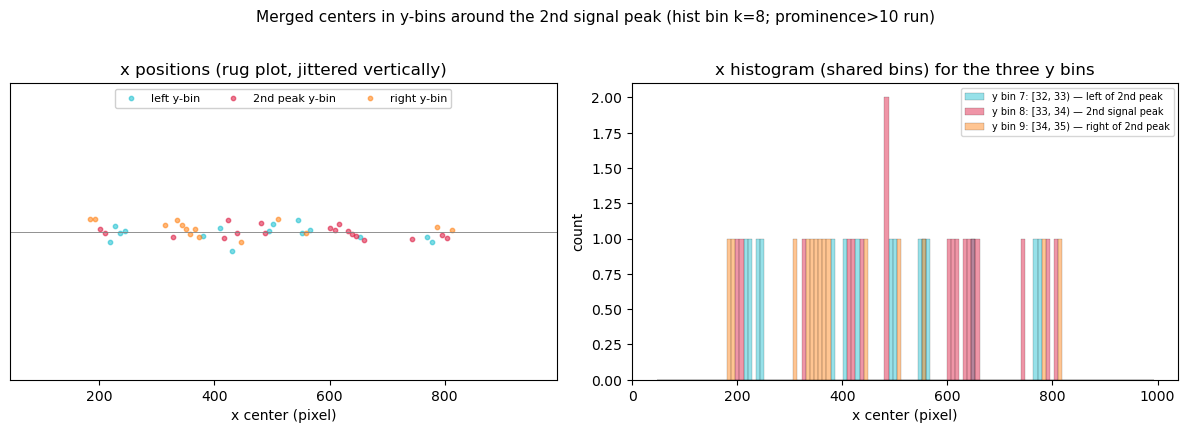

y bin 7: [32, 33) — left of 2nd peak
  n=15,  x min/mean/max = 218.31, 467.08, 777.60
y bin 8: [33, 34) — 2nd signal peak
  n=18,  x min/mean/max = 200.61, 540.54, 803.85
y bin 9: [34, 35) — right of 2nd peak
  n=14,  x min/mean/max = 182.95, 423.39, 812.69


In [5]:
"""For the 2nd signal peak (by y) and its ±1 y-bins: plot x coordinates of all merged centers in those bins."""

from scipy.signal import find_peaks

for name in ("x_arr", "y_arr", "bin_edges"):
    if name not in globals():
        raise RuntimeError("Run the first code cell first (defines x_arr, y_arr, bin_edges).")

if x_arr.shape != y_arr.shape:
    raise RuntimeError("x_arr and y_arr must have the same length; re-run the first cell.")

HIST_PROMINENCE = 10
counts, _ = np.histogram(y_arr, bins=bin_edges)
_c = counts.astype(float)
_p = np.concatenate([[0.0], _c, [0.0]])
_ixp, _ = find_peaks(_p, prominence=HIST_PROMINENCE)
peak_ix = _ixp - 1
peak_ix = peak_ix[(peak_ix >= 0) & (peak_ix < counts.size)]
if peak_ix.size < 2:
    raise RuntimeError("Need at least 2 histogram peaks (prominence > 10) to select the 2nd peak.")

peak_y_centers = 0.5 * (bin_edges[peak_ix] + bin_edges[peak_ix + 1])
sort_order = np.argsort(peak_y_centers)
peak_ix_sorted = peak_ix[sort_order]

i_second = 1
k = int(peak_ix_sorted[i_second])  # histogram bin index of the 2nd signal peak
k_lo, k_mid, k_hi = k - 1, k, k + 1
if k_lo < 0 or k_hi >= counts.size:
    raise RuntimeError("2nd peak bin is at the y histogram edge; no full ±1 bin neighborhood.")

long_labels = (
    f"y bin {k_lo}: [{bin_edges[k_lo]:.0f}, {bin_edges[k_lo + 1]:.0f}) — left of 2nd peak",
    f"y bin {k_mid}: [{bin_edges[k_mid]:.0f}, {bin_edges[k_mid + 1]:.0f}) — 2nd signal peak",
    f"y bin {k_hi}: [{bin_edges[k_hi]:.0f}, {bin_edges[k_hi + 1]:.0f}) — right of 2nd peak",
)
short_labels = ("left y-bin", "2nd peak y-bin", "right y-bin")
colors = ("tab:cyan", "crimson", "tab:orange")
masks = [
    (y_arr >= bin_edges[k_lo]) & (y_arr < bin_edges[k_lo + 1]),
    (y_arr >= bin_edges[k_mid]) & (y_arr < bin_edges[k_mid + 1]),
    (y_arr >= bin_edges[k_hi]) & (y_arr < bin_edges[k_hi + 1]),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
rng_draw = np.random.default_rng(0)

ax0 = axes[0]
for msk, sl, c in zip(masks, short_labels, colors):
    xx = x_arr[msk]
    ax0.scatter(
        xx,
        rng_draw.normal(0.0, 0.02, size=xx.size),
        s=10,
        alpha=0.55,
        c=c,
        label=sl,
    )
xr = (float(x_arr.min()), float(x_arr.max())) if x_arr.size else (0.0, 1.0)
ax0.set_xlim(xr[0] - 2, xr[1] + 2)
ax0.set_ylim(-0.35, 0.35)
ax0.set_yticks([])
ax0.set_xlabel("x center (pixel)")
ax0.set_title("x positions (rug plot, jittered vertically)")
ax0.legend(loc="upper center", fontsize=8, ncol=3, framealpha=0.92)
ax0.axhline(0, color="0.5", lw=0.6)

n_x_bins = max(24, int(np.clip((xr[1] - xr[0]) / 5.0, 40, 120)))
x_hist_edges = np.linspace(xr[0], xr[1], n_x_bins + 1)

ax1 = axes[1]
for msk, lab, c in zip(masks, long_labels, colors):
    xx = x_arr[msk]
    ax1.hist(
        xx,
        bins=x_hist_edges,
        alpha=0.45,
        color=c,
        label=lab,
        edgecolor="black",
        linewidth=0.25,
    )
ax1.set_xlabel("x center (pixel)")
ax1.set_ylabel("count")
ax1.set_title("x histogram (shared bins) for the three y bins")
ax1.legend(fontsize=7, loc="best")

fig.suptitle(
    f"Merged centers in y-bins around the 2nd signal peak (hist bin k={k}; prominence>10 run)",
    fontsize=11,
    y=1.02,
)
fig.tight_layout()
plt.show()

for msk, lab in zip(masks, long_labels):
    xx = x_arr[msk]
    if xx.size:
        print(f"{lab}\n  n={xx.size},  x min/mean/max = {xx.min():.2f}, {xx.mean():.2f}, {xx.max():.2f}")
    else:
        print(f"{lab}\n  n=0")


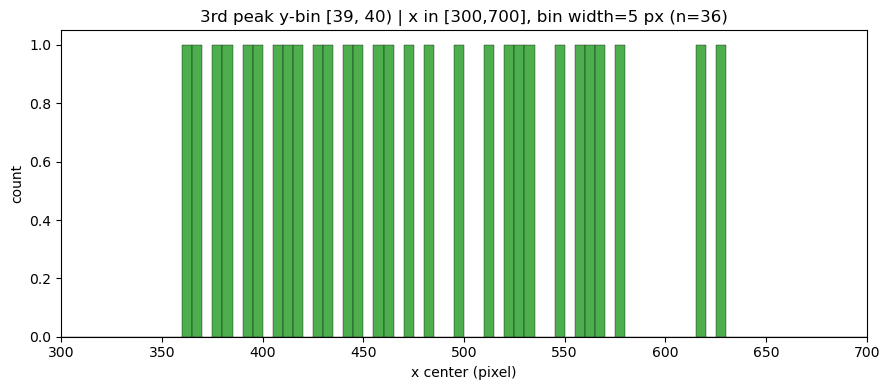

y-bin [39, 40): n=36, x mean=492.58, std=161.91, min=136.88, max=875.23


In [7]:
"""x distribution of merged centers in the y-histogram bin of the 3rd signal peak (prominence > 10, sorted by y)."""

from scipy.signal import find_peaks

for name in ("x_arr", "y_arr", "bin_edges"):
    if name not in globals():
        raise RuntimeError("Run the first code cell first (defines x_arr, y_arr, bin_edges).")

HIST_PROMINENCE = 10
counts, _ = np.histogram(y_arr, bins=bin_edges)
_c = counts.astype(float)
_p = np.concatenate([[0.0], _c, [0.0]])
_ixp, _ = find_peaks(_p, prominence=HIST_PROMINENCE)
peak_ix = _ixp - 1
peak_ix = peak_ix[(peak_ix >= 0) & (peak_ix < counts.size)]
if peak_ix.size < 3:
    raise RuntimeError("Need at least 3 histogram peaks (prominence > 10) for the 3rd peak bin.")

peak_y_centers = 0.5 * (bin_edges[peak_ix] + bin_edges[peak_ix + 1])
sort_order = np.argsort(peak_y_centers)
peak_ix_sorted = peak_ix[sort_order]

k = int(peak_ix_sorted[2])
y0, y1 = float(bin_edges[k]), float(bin_edges[k + 1])
msk = (y_arr >= y0) & (y_arr < y1)
xx = x_arr[msk]

# x histogram: fixed display range and 5 px bin width
X_LO, X_HI = 300, 700
X_BIN = 5.0
x_hist_edges = np.arange(X_LO, X_HI + X_BIN, X_BIN)

fig, ax = plt.subplots(figsize=(9, 4.0))
if xx.size:
    ax.hist(
        xx,
        bins=x_hist_edges,
        color="tab:green",
        edgecolor="black",
        linewidth=0.3,
        alpha=0.85,
    )
else:
    ax.text(0.5, 0.5, "no points in this bin", ha="center", va="center", transform=ax.transAxes)

ax.set_xlim(X_LO, X_HI)
ax.set_xlabel("x center (pixel)")
ax.set_ylabel("count")
ax.set_title(
    f"3rd peak y-bin [{y0:.0f}, {y1:.0f}) | x in [{X_LO},{X_HI}], bin width={X_BIN:g} px (n={xx.size})"
)
fig.tight_layout()
plt.show()

if xx.size:
    print(
        f"y-bin [{y0:.0f}, {y1:.0f}): n={xx.size}, "
        f"x mean={xx.mean():.2f}, std={xx.std():.2f}, min={xx.min():.2f}, max={xx.max():.2f}"
    )


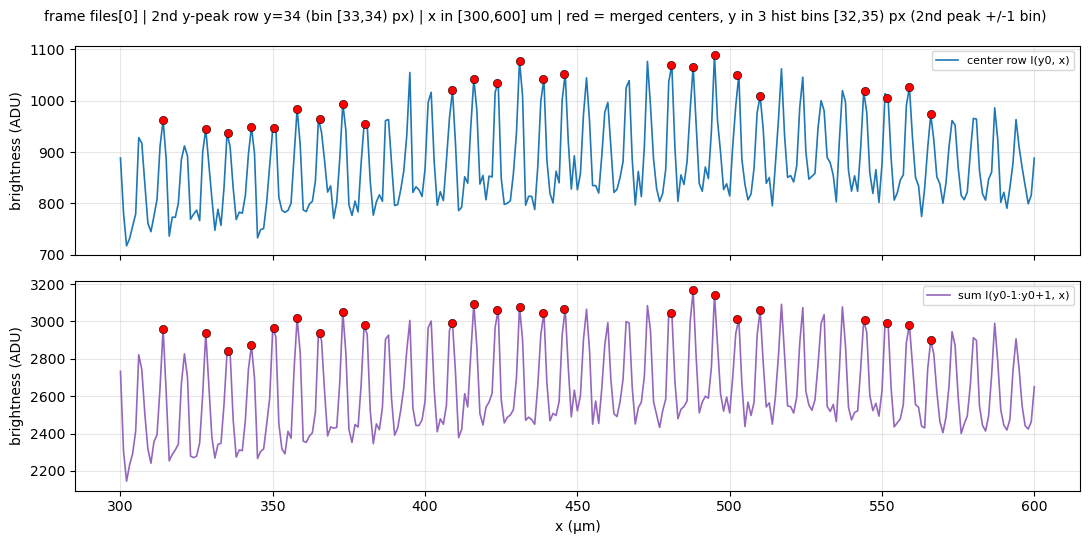

In [3]:
"""2nd y-histogram peak row: full-x brightness (400-500 um) - center row vs sum of +/-1 rows; merged peaks marked."""

from scipy.signal import find_peaks

for name in ("y_arr", "bin_edges", "x_arr", "fid_arr", "files"):
    if name not in globals():
        raise RuntimeError("Run the first code cell first.")

UM_PER_PIXEL = 1.0  # µm / pixel
X_UM_LO, X_UM_HI = 300.0, 600.0

HIST_PROMINENCE = 10
counts, _ = np.histogram(y_arr, bins=bin_edges)
_c = counts.astype(float)
_p = np.concatenate([[0.0], _c, [0.0]])
_ixp, _ = find_peaks(_p, prominence=HIST_PROMINENCE)
peak_ix = _ixp - 1
peak_ix = peak_ix[(peak_ix >= 0) & (peak_ix < counts.size)]
if peak_ix.size < 2:
    raise RuntimeError("Need at least 2 histogram peaks (prominence > 10).")

peak_y_centers = 0.5 * (bin_edges[peak_ix] + bin_edges[peak_ix + 1])
sort_order = np.argsort(peak_y_centers)
k = int(peak_ix[sort_order][1])
y_a, y_b = float(bin_edges[k]), float(bin_edges[k + 1])
_row_ref = int(round(0.5 * (y_a + y_b)))

x_um_all = x_arr * UM_PER_PIXEL
# annotate merged centers in 2nd peak bin plus its +/-1 y-bins (same 1-px hist bins)
_n_yb = int(len(counts))
_k_lo = max(0, k - 1)
_k_hi = min(_n_yb - 1, k + 1)
_y_ann_lo = float(bin_edges[_k_lo])
_y_ann_hi = float(bin_edges[_k_hi + 1])
peak_point_msk = (
    (y_arr >= _y_ann_lo) & (y_arr < _y_ann_hi)
    & (x_um_all >= X_UM_LO) & (x_um_all <= X_UM_HI)
)

_cache_img: dict[int, np.ndarray] = {}


def _load_im(fid: int) -> np.ndarray:
    if fid not in _cache_img:
        _cache_img[fid] = np.asarray(np.load(files[fid]), dtype=np.float64)
    return _cache_img[fid]


def _row_profiles(im: np.ndarray, yr: int, x_um_lo: float, x_um_hi: float, um_px: float):
    h, w = im.shape
    yr = int(np.clip(yr, 0, h - 1))
    x_lo = max(0, int(np.floor(x_um_lo / um_px)))
    x_hi = min(w - 1, int(np.ceil(x_um_hi / um_px)))
    xs = np.arange(x_lo, x_hi + 1, dtype=np.int64)
    x_axis_um = xs.astype(np.float64) * um_px
    center = im[yr, xs].astype(np.float64)
    y0, y1 = max(0, yr - 1), min(h, yr + 2)
    three_sum = np.sum(im[y0:y1, xs], axis=0).astype(np.float64)
    return x_axis_um, center, three_sum, x_lo, x_hi


fids_to_plot = sorted(np.unique(fid_arr).tolist())
for fid in fids_to_plot:
    im = _load_im(int(fid))
    h, w = im.shape
    yr_use = int(np.clip(_row_ref, 0, h - 1))

    x_um_axis, prof_c, prof_3, x_lo, x_hi = _row_profiles(
        im, yr_use, X_UM_LO, X_UM_HI, UM_PER_PIXEL,
    )

    fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(11, 5.5), sharex=True)
    ax0.plot(x_um_axis, prof_c, "-", color="tab:blue", lw=1.2, label="center row I(y0, x)")
    ax1.plot(x_um_axis, prof_3, "-", color="tab:purple", lw=1.2, label="sum I(y0-1:y0+1, x)")

    sub = peak_point_msk & (fid_arr == fid)
    if np.any(sub):
        for i in np.flatnonzero(sub):
            xi = int(np.clip(round(float(x_arr[i])), 0, w - 1))
            if x_lo <= xi <= x_hi:
                xu = float(x_um_all[i])
                ic = float(im[yr_use, xi])
                ax0.scatter([xu], [ic], c="red", s=36, zorder=5, edgecolors="k", linewidths=0.4)
                y0b, y1b = max(0, yr_use - 1), min(h, yr_use + 2)
                i3 = float(np.sum(im[y0b:y1b, xi]))
                ax1.scatter([xu], [i3], c="red", s=36, zorder=5, edgecolors="k", linewidths=0.4)

    ax0.set_ylabel("brightness (ADU)")
    ax0.legend(loc="upper right", fontsize=8)
    ax0.grid(True, alpha=0.3)
    ax1.set_xlabel("x (µm)")
    ax1.set_ylabel("brightness (ADU)")
    ax1.legend(loc="upper right", fontsize=8)
    ax1.grid(True, alpha=0.3)
    fig.suptitle(
        f"frame files[{fid}] | 2nd y-peak row y={yr_use} (bin [{y_a:.0f},{y_b:.0f}) px) | "
        f"x in [{X_UM_LO:g},{X_UM_HI:g}] um | red = merged centers, y in 3 hist bins "
        f"[{_y_ann_lo:.0f},{_y_ann_hi:.0f}) px (2nd peak +/-1 bin)",
        fontsize=10,
    )
    fig.tight_layout()
    plt.show()

if len(fids_to_plot) > 1:
    print(f"Plotted {len(fids_to_plot)} frames (one figure each); fids={fids_to_plot}")


C:\Users\32769\AppData\Local\Temp\ipykernel_7860\3645935425.py:123: UserWarning: Glyph 31532 (\N{CJK UNIFIED IDEOGRAPH-7B2C}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\32769\AppData\Local\Temp\ipykernel_7860\3645935425.py:123: UserWarning: Glyph 20108 (\N{CJK UNIFIED IDEOGRAPH-4E8C}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\32769\AppData\Local\Temp\ipykernel_7860\3645935425.py:123: UserWarning: Glyph 23792 (\N{CJK UNIFIED IDEOGRAPH-5CF0}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\32769\AppData\Local\Temp\ipykernel_7860\3645935425.py:123: UserWarning: Glyph 34892 (\N{CJK UNIFIED IDEOGRAPH-884C}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\32769\AppData\Local\Temp\ipykernel_7860\3645935425.py:123: UserWarning: Glyph 21521 (\N{CJK UNIFIED IDEOGRAPH-5411}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\32769\AppData\Local\Temp\ipykernel_7860\3645935425.py:123: UserWarning: Glyph 31163 (\

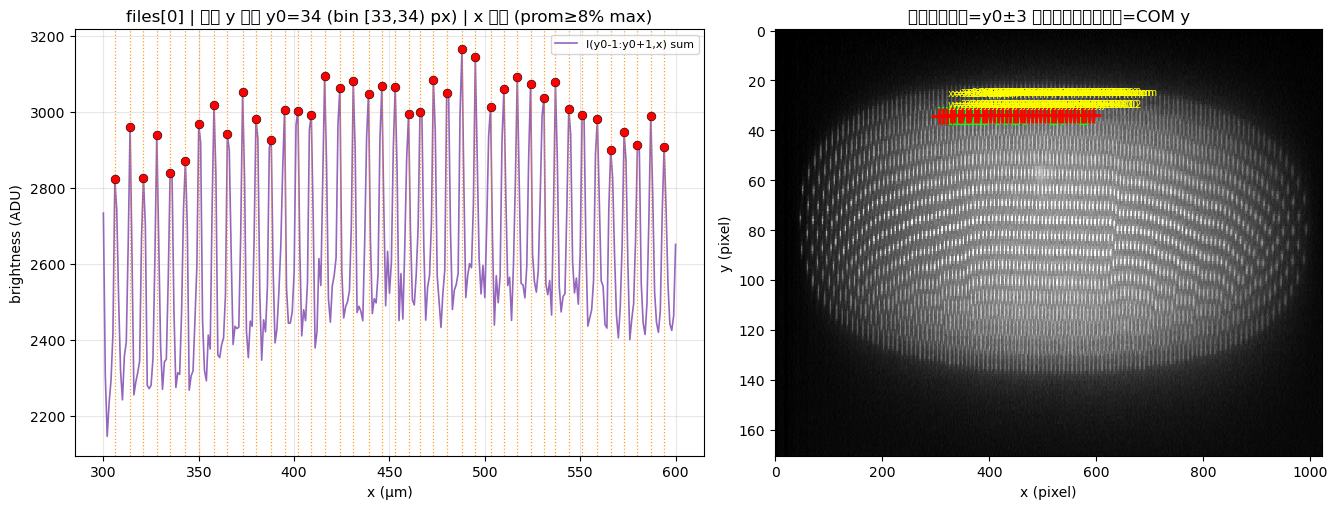

frame [0]  x 峰数=41 | x=306.00µm (306px), y_fit=34.06, 剖面高=2822.0; x=314.00µm (314px), y_fit=34.09, 剖面高=2960.7; x=321.00µm (321px), y_fit=34.06, 剖面高=2826.9; x=328.00µm (328px), y_fit=34.01, 剖面高=2939.7; x=335.00µm (335px), y_fit=34.05, 剖面高=2839.5; x=343.00µm (343px), y_fit=34.02, 剖面高=2871.6; x=350.00µm (350px), y_fit=33.99, 剖面高=2967.1; x=358.00µm (358px), y_fit=34.03, 剖面高=3018.3; x=365.00µm (365px), y_fit=33.99, 剖面高=2940.6; x=373.00µm (373px), y_fit=34.00, 剖面高=3051.2; x=380.00µm (380px), y_fit=33.99, 剖面高=2981.8; x=388.00µm (388px), y_fit=33.98, 剖面高=2927.0; x=395.00µm (395px), y_fit=33.99, 剖面高=3005.6; x=402.00µm (402px), y_fit=33.96, 剖面高=3002.3; x=409.00µm (409px), y_fit=33.93, 剖面高=2992.5; x=416.00µm (416px), y_fit=33.94, 剖面高=3093.3; x=424.00µm (424px), y_fit=33.94, 剖面高=3063.8; x=431.00µm (431px), y_fit=33.94, 剖面高=3080.2; x=439.00µm (439px), y_fit=33.96, 剖面高=3047.9; x=446.00µm (446px), y_fit=33.98, 剖面高=3068.1; x=453.00µm (453px), y_fit=33.91, 剖面高=3065.6; x=460.00µm (460px), y_fit=33.96, 剖

In [4]:
"""第二 y 直方图峰：用中心行 y0 与 y0±1 三行沿 x 的亮度和找 x 向峰；在每个 x 峰位置取 y0±3 行做 COM 拟合 y；在离子图上画 7 行区域与峰位。"""

from matplotlib.patches import Rectangle
from scipy.signal import find_peaks

for name in ("y_arr", "bin_edges", "files", "fid_arr"):
    if name not in globals():
        raise RuntimeError("请先运行首格以定义 y_arr、bin_edges、files、fid_arr。")

UM_PER_PIXEL = 1.0
X_UM_LO, X_UM_HI = 300.0, 600.0
PROF_PEAK_PROMINENCE_FRAC = 0.08
PROF_PEAK_DISTANCE_PX = 4
Y_HALFWIN = 3

HIST_PROMINENCE = 10
counts, _ = np.histogram(y_arr, bins=bin_edges)
_c = counts.astype(float)
_p = np.concatenate([[0.0], _c, [0.0]])
_ixp, _ = find_peaks(_p, prominence=HIST_PROMINENCE)
peak_ix = _ixp - 1
peak_ix = peak_ix[(peak_ix >= 0) & (peak_ix < counts.size)]
if peak_ix.size < 2:
    raise RuntimeError("至少需要 2 个 y 直方图峰 (prominence>10)。")

peak_y_centers = 0.5 * (bin_edges[peak_ix] + bin_edges[peak_ix + 1])
sort_order = np.argsort(peak_y_centers)
k = int(peak_ix[sort_order][1])
y_a, y_b = float(bin_edges[k]), float(bin_edges[k + 1])
_row_ref = int(round(0.5 * (y_a + y_b)))

_cache_img: dict[int, np.ndarray] = {}


def _load_im(fid: int) -> np.ndarray:
    if fid not in _cache_img:
        _cache_img[fid] = np.asarray(np.load(files[fid]), dtype=np.float64)
    return _cache_img[fid]


def _row_profiles(im: np.ndarray, yr: int, x_um_lo: float, x_um_hi: float, um_px: float):
    h, w = im.shape
    yr = int(np.clip(yr, 0, h - 1))
    x_lo = max(0, int(np.floor(x_um_lo / um_px)))
    x_hi = min(w - 1, int(np.ceil(x_um_hi / um_px)))
    xs = np.arange(x_lo, x_hi + 1, dtype=np.int64)
    x_axis_um = xs.astype(np.float64) * um_px
    center = im[yr, xs].astype(np.float64)
    y0, y1 = max(0, yr - 1), min(h, yr + 2)
    three_sum = np.sum(im[y0:y1, xs], axis=0).astype(np.float64)
    return x_axis_um, center, three_sum, x_lo, x_hi, xs


fids = sorted(np.unique(fid_arr).tolist())

for fid in fids:
    im = _load_im(int(fid))
    h, w = im.shape
    yr0 = int(np.clip(_row_ref, 0, h - 1))
    x_um_axis, _prof_c, prof_3, x_lo, x_hi, xs_pix = _row_profiles(
        im, yr0, X_UM_LO, X_UM_HI, UM_PER_PIXEL,
    )

    pmax = float(np.max(prof_3)) if prof_3.size else 0.0
    prom = max(pmax * PROF_PEAK_PROMINENCE_FRAC, 1e-9)
    ix_peaks, _props = find_peaks(
        prof_3.astype(float),
        prominence=prom,
        distance=max(1, int(PROF_PEAK_DISTANCE_PX)),
    )

    rows_fit: list[tuple[int, float, float, int, int, float]] = []
    for ix in ix_peaks:
        x_px = int(xs_pix[ix])
        x_px = int(np.clip(x_px, 0, w - 1))
        r0 = max(0, yr0 - Y_HALFWIN)
        r1 = min(h, yr0 + Y_HALFWIN + 1)
        col = im[r0:r1, x_px].astype(np.float64)
        col = np.maximum(col, 0.0)
        s = float(np.sum(col))
        if s <= 0.0:
            continue
        y_idx = np.arange(r0, r1, dtype=np.float64)
        y_fit = float(np.sum(y_idx * col) / s)
        rows_fit.append(
            (x_px, float(x_um_axis[ix]), y_fit, r0, r1, float(prof_3[ix])),
        )

    fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2), gridspec_kw={"width_ratios": [1.15, 1.0]})
    axp, axm = axes[0], axes[1]

    axp.plot(x_um_axis, prof_3, "-", color="tab:purple", lw=1.2, label="I(y0-1:y0+1,x) sum")
    for x_px, x_um_p, y_fit, _r0, _r1, pht in rows_fit:
        axp.axvline(x_um_p, color="darkorange", ls=":", lw=0.9, alpha=0.85)
        axp.scatter([x_um_p], [pht], c="red", s=40, zorder=6, edgecolors="k", lw=0.4)
    axp.set_xlabel("x (µm)")
    axp.set_ylabel("brightness (ADU)")
    axp.set_title(
        f"files[{fid}] | 第二 y 峰行 y0={yr0} (bin [{y_a:.0f},{y_b:.0f}) px) | x 向峰 (prom≥{100*PROF_PEAK_PROMINENCE_FRAC:.0f}% max)",
    )
    axp.legend(loc="upper right", fontsize=8)
    axp.grid(True, alpha=0.3)

    vmin, vmax = np.percentile(im, [1.5, 99.5])
    axm.imshow(im, cmap="gray", vmin=vmin, vmax=vmax, aspect="auto", origin="upper", interpolation="nearest")
    axm.set_xlabel("x (pixel)")
    axm.set_ylabel("y (pixel)")
    for x_px, x_um_p, y_fit, r0, r1, _pht in rows_fit:
        rect = Rectangle(
            (x_px - 0.5, r0 - 0.5),
            1.0,
            (r1 - r0),
            linewidth=1.6,
            edgecolor="lime",
            facecolor="none",
        )
        axm.add_patch(rect)
        axm.plot([x_px], [y_fit], "+", color="red", ms=11, mew=2.0)
        axm.annotate(
            f"x={x_um_p:.1f}µm\ny={y_fit:.2f}",
            xy=(x_px, y_fit),
            xytext=(6, 6),
            textcoords="offset points",
            fontsize=7,
            color="yellow",
        )
    axm.set_title("离子图：绿框=y0±3 行拟合窗口，红十字=COM y")
    fig.tight_layout()
    plt.show()

    print(
        f"frame [{fid}]  x 峰数={len(rows_fit)} | "
        + "; ".join(
            f"x={t[1]:.2f}µm ({t[0]}px), y_fit={t[2]:.2f}, 剖面高={t[5]:.1f}"
            for t in rows_fit
        ),
    )
